# 04 — Principal Component Analysis
### From Orthogonal Projections to Probabilistic PCA

---

> **Position in the series:**
> `01_statistical_learning_theory` → `02_pac_and_vc_dimensions` → `03_linear_algebra_and_geometry` → **`04_pca`** → `05_gaussian_mixture_models` → `06_linear_regression` → `07_logistic_regression` → `08_svm_and_kernel_methods`

## References

| # | Source |
|---|--------|
| [1] | C. M. Bishop — *Pattern Recognition and Machine Learning*, Springer, 2006 — Ch. 12 (Continuous Latent Variables), §12.1 PCA, §12.2 Probabilistic PCA |
| [2] | M. P. Deisenroth, A. A. Faisal & C. S. Ong — *Mathematics for Machine Learning*, Cambridge University Press, 2020 — Ch. 3.8 (Orthogonal Projections), Ch. 4.5 (SVD), Ch. 10 (Dimensionality Reduction with PCA) |
| [3] | Iacopo Masi — *Dimensionality Reduction & PCA*, lecture slides, Sapienza SMIA |
| [4] | M. E. Tipping & C. M. Bishop — *Probabilistic Principal Component Analysis*, JRSS B, 61(3), 1999 |
| [5] | T. Hastie, R. Tibshirani & J. Friedman — *The Elements of Statistical Learning*, 2nd ed., Springer, 2009 — §14.5.1 |
| [6] | K. P. Murphy — *Machine Learning: A Probabilistic Perspective*, MIT Press, 2012 — Ch. 12 |

---

## Structure
1. Motivation: High-Dimensional Data, Redundancy and the Curse of Dimensionality
2. Orthogonal Projections: onto a Line and onto a Subspace
3. Centering the Data and the Covariance Matrix
4. PCA as Maximum Variance
5. PCA as Minimum Reconstruction Error
6. Implementation From Scratch: PCA on a 2D Dataset
7. Explained Variance and the Choice of $k$
8. PCA via the Singular Value Decomposition
9. Real Example: Compressing Handwritten Digits
10. Probabilistic PCA I: The Generative Model
11. Probabilistic PCA II: Closed-Form Maximum Likelihood
12. Probabilistic PCA III: The Posterior and the Limit $\sigma^2\to0$
13. Comparison with `sklearn.decomposition.PCA`
14. Summary

---
## 1. Motivation: High-Dimensional Data, Redundancy and the Curse of Dimensionality

Modern datasets live in high dimension: an $8\times8$ grayscale image is a point in $\mathbb R^{64}$, a $28\times28$ MNIST digit a point in $\mathbb R^{784}$, a gene-expression profile a point in $\mathbb R^{20000}$. Two observations make this less hopeless than it sounds.

**1. Features are redundant.** Neighbouring pixels are strongly correlated; many sensor channels measure almost the same physical quantity. When features are correlated, the data does not fill $\mathbb R^D$ — it concentrates near a **lower-dimensional subspace** (or, more generally, manifold). Bishop's example (§12, intro): take one image of a digit and translate/rotate it inside a larger canvas. Every resulting image is a point in $\mathbb R^{D}$, yet only **3 degrees of freedom** (two translations, one rotation) generate them all — the *intrinsic dimensionality* is 3.

**2. High dimension is actively harmful — the curse of dimensionality.** Geometric intuition from 2D/3D breaks down:
- *Volume concentrates in the shell.* The fraction of a unit $D$-ball lying in the thin shell between radius $1-\varepsilon$ and $1$ is $1-(1-\varepsilon)^D\to1$ as $D\to\infty$ (Bishop §1.4).
- *Distances concentrate.* For random points, the ratio between the farthest and the nearest neighbour distance tends to $1$: "near" and "far" lose meaning, which hurts every distance-based method (k-NN, k-means, kernels).
- *Sample complexity explodes.* Covering a cube with cells of side $1/10$ needs $10^D$ cells — the number of samples needed to "see" every region grows exponentially in $D$ (cf. the capacity arguments of `02_pac_and_vc_dimensions`).

**Dimensionality reduction** addresses both points: find a map $\mathbb R^D\to\mathbb R^k$, $k\ll D$, that keeps the information that matters and discards redundancy and noise. **PCA** is the canonical *linear* answer, and the goal of this notebook is to derive it in three equivalent ways (max variance, min reconstruction error, max likelihood of a latent-variable model).

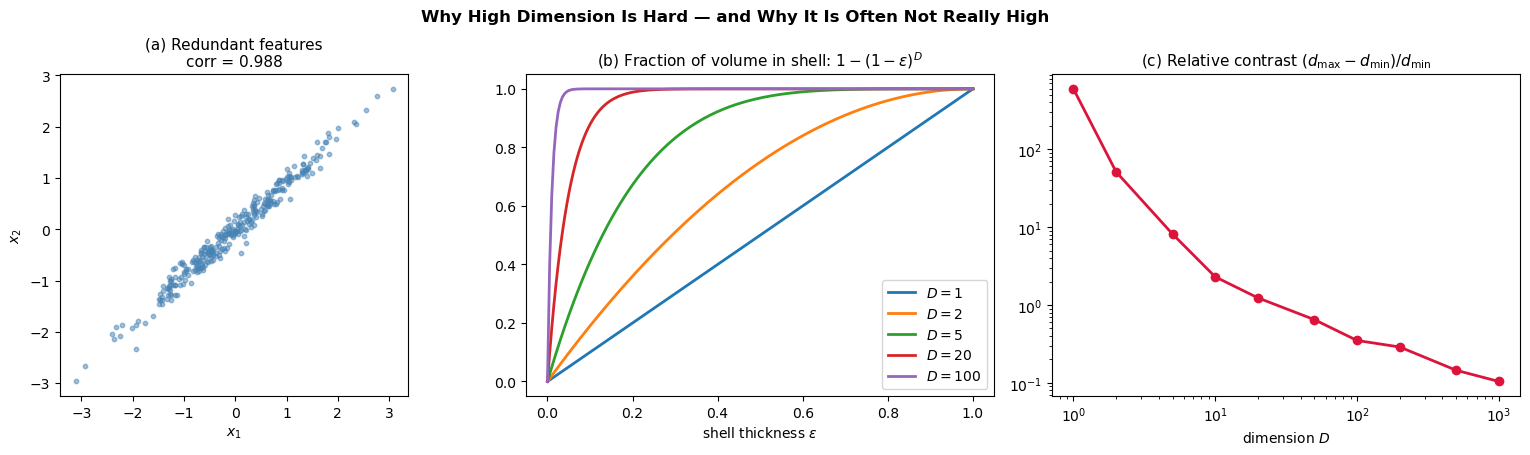

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) Redundancy: two strongly correlated features -> data close to a 1D subspace
t = rng.normal(size=300)
X_red = np.column_stack([t, 0.9 * t + 0.15 * rng.normal(size=300)])
axes[0].scatter(X_red[:, 0], X_red[:, 1], s=10, alpha=0.5, color="steelblue")
axes[0].set_title(f"(a) Redundant features\ncorr = {np.corrcoef(X_red.T)[0, 1]:.3f}", fontsize=11)
axes[0].set_xlabel("$x_1$"); axes[0].set_ylabel("$x_2$"); axes[0].set_aspect("equal")

# (b) Volume of a D-ball concentrated in the outer shell [1-eps, 1]
eps = np.linspace(0, 1, 200)
for D in [1, 2, 5, 20, 100]:
    axes[1].plot(eps, 1 - (1 - eps) ** D, lw=2, label=f"$D={D}$")
axes[1].set_title(r"(b) Fraction of volume in shell: $1-(1-\varepsilon)^D$", fontsize=11)
axes[1].set_xlabel(r"shell thickness $\varepsilon$"); axes[1].legend()

# (c) Distance concentration: (d_max - d_min) / d_min shrinks with D
dims = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
contrast = []
for D in dims:
    P = rng.uniform(size=(500, D))
    q = rng.uniform(size=D)
    d = np.linalg.norm(P - q, axis=1)
    contrast.append((d.max() - d.min()) / d.min())
axes[2].loglog(dims, contrast, "o-", color="crimson", lw=2)
axes[2].set_title(r"(c) Relative contrast $(d_{\max}-d_{\min})/d_{\min}$", fontsize=11)
axes[2].set_xlabel("dimension $D$")

plt.suptitle("Why High Dimension Is Hard — and Why It Is Often Not Really High", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. Orthogonal Projections: onto a Line and onto a Subspace

PCA *projects* data onto a subspace, so we first need projections precisely (Deisenroth §3.8). A linear map $\pi:\mathbb R^D\to U\subseteq\mathbb R^D$ is a **projection** if $\pi^2=\pi$ (projecting twice changes nothing); it is **orthogonal** if, in addition, the residual $\mathbf x-\pi(\mathbf x)$ is orthogonal to $U$.

### Projection onto a line

Let $U=\operatorname{span}(\mathbf b)$, $\mathbf b\in\mathbb R^D$. The projection is a multiple of the basis vector, $\pi_U(\mathbf x)=\lambda\mathbf b$, and $\lambda$ is fixed by the orthogonality condition:

$$
\langle\mathbf x-\lambda\mathbf b,\ \mathbf b\rangle=0
\;\Longrightarrow\;
\lambda=\frac{\mathbf b^\top\mathbf x}{\mathbf b^\top\mathbf b},
\qquad
\pi_U(\mathbf x)=\frac{\mathbf b\mathbf b^\top}{\mathbf b^\top\mathbf b}\,\mathbf x =: P_\pi\,\mathbf x .
$$

If $\lVert\mathbf b\rVert=1$ this simplifies to $\lambda=\mathbf b^\top\mathbf x$ — the **coordinate** of the projection along $\mathbf b$ — and $P_\pi=\mathbf b\mathbf b^\top$, a rank-1 matrix.

### Projection onto a subspace

Let $U=\operatorname{span}(\mathbf b_1,\dots,\mathbf b_k)$ and collect the basis in $B=[\mathbf b_1|\cdots|\mathbf b_k]\in\mathbb R^{D\times k}$ (full column rank). Now $\pi_U(\mathbf x)=B\boldsymbol\lambda$ with $\boldsymbol\lambda\in\mathbb R^k$, and orthogonality to **every** basis vector reads

$$
B^\top(\mathbf x-B\boldsymbol\lambda)=\mathbf 0
\;\Longrightarrow\;
\underbrace{B^\top B\,\boldsymbol\lambda=B^\top\mathbf x}_{\text{normal equations}}
\;\Longrightarrow\;
\boldsymbol\lambda=(B^\top B)^{-1}B^\top\mathbf x .
$$

Hence

$$
\boxed{\;\pi_U(\mathbf x)=P\,\mathbf x,\qquad P=B\,(B^\top B)^{-1}B^\top\;}
$$

Properties (easy to check): $P^2=P$ (idempotent), $P^\top=P$ (symmetric), $\operatorname{rank}P=k$, eigenvalues in $\{0,1\}$, and $I-P$ is the projection onto $U^\perp$.

**Orthonormal basis.** If $B^\top B=I_k$ the inverse disappears: $P=BB^\top$ and the coordinates are simply $\boldsymbol\lambda=B^\top\mathbf x$. PCA will always produce an orthonormal basis, so this is the case we will use. Note also that $\pi_U(\mathbf x)$ is the point of $U$ **closest** to $\mathbf x$ (Pythagoras: $\lVert\mathbf x-\mathbf u\rVert^2=\lVert\mathbf x-P\mathbf x\rVert^2+\lVert P\mathbf x-\mathbf u\rVert^2$ for every $\mathbf u\in U$) — this is the seed of the "minimum reconstruction error" view of Section 5.

> **ML Bridge:** the normal equations above are *exactly* those of least squares: linear regression (`06_linear_regression`) projects the target vector $\mathbf y$ onto the column space of the design matrix $X$, with $P=X(X^\top X)^{-1}X^\top$ (the "hat matrix").

P^2 = P        : True
P^T = P        : True
rank(P)        : 2
eigenvalues(P) : [-0.  1.  1.]
residuals orthogonal to U: True
B(B^T B)^-1 B^T == Q Q^T : True


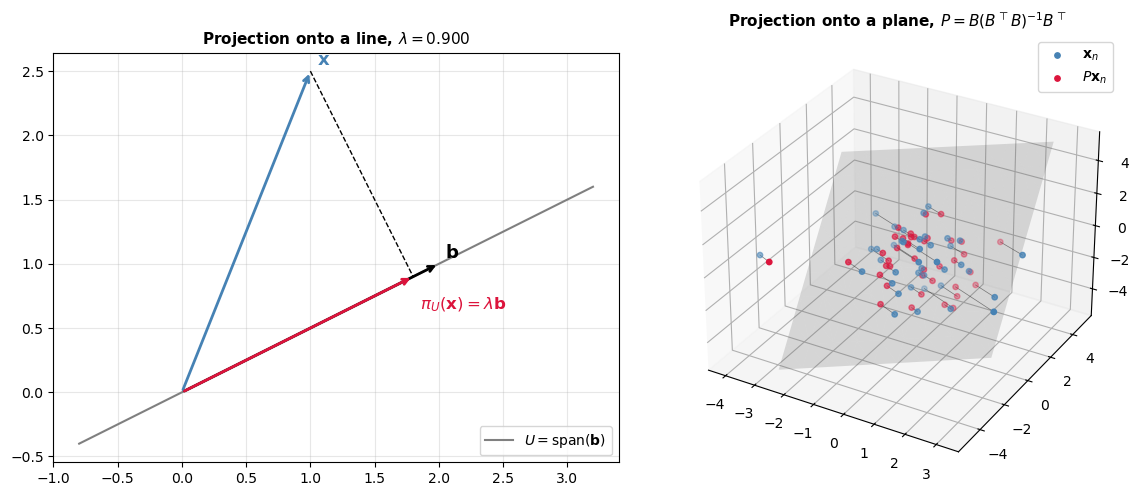

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def projection_matrix(B):
    # Orthogonal projection onto the column space of B (D x k, full column rank)
    return B @ np.linalg.inv(B.T @ B) @ B.T

# --- Projection onto a line in R^2 ---
b = np.array([2.0, 1.0])
x = np.array([1.0, 2.5])
P_line = projection_matrix(b[:, None])
x_proj = P_line @ x
lam = b @ x / (b @ b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
s = np.linspace(-0.4, 1.6, 2)
ax.plot(s * b[0], s * b[1], color="gray", lw=1.5, label=r"$U=\mathrm{span}(\mathbf{b})$")
ax.annotate("", xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="black", lw=2))
ax.annotate("", xy=x, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="steelblue", lw=2))
ax.annotate("", xy=x_proj, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color="crimson", lw=2))
ax.plot([x[0], x_proj[0]], [x[1], x_proj[1]], "k--", lw=1)
ax.text(*b + 0.05, r"$\mathbf{b}$", fontsize=13)
ax.text(*x + 0.05, r"$\mathbf{x}$", fontsize=13, color="steelblue")
ax.text(x_proj[0] + 0.05, x_proj[1] - 0.25, r"$\pi_U(\mathbf{x})=\lambda\mathbf{b}$", fontsize=12, color="crimson")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(loc="lower right")
ax.set_title(fr"Projection onto a line, $\lambda={lam:.3f}$", fontsize=11, fontweight="bold")

# --- Projection onto a plane in R^3 ---
rng = np.random.default_rng(1)
B = np.array([[1.0, 0.0], [1.0, 1.0], [0.0, 2.0]])     # non-orthonormal basis of a plane
P = projection_matrix(B)
X3 = rng.normal(size=(40, 3)) * 1.5
X3_proj = X3 @ P.T

print("P^2 = P        :", np.allclose(P @ P, P))
print("P^T = P        :", np.allclose(P, P.T))
print("rank(P)        :", np.linalg.matrix_rank(P))
print("eigenvalues(P) :", np.round(np.linalg.eigvalsh(P), 6))
print("residuals orthogonal to U:", np.allclose(B.T @ (X3 - X3_proj).T, 0))

# Orthonormal basis of the same plane (via QR) gives the same P = Q Q^T
Q, _ = np.linalg.qr(B)
print("B(B^T B)^-1 B^T == Q Q^T :", np.allclose(P, Q @ Q.T))

axes[1].remove()
ax3 = fig.add_subplot(1, 2, 2, projection="3d")
uu, vv = np.meshgrid(np.linspace(-2.5, 2.5, 10), np.linspace(-2.5, 2.5, 10))
plane = B[:, [0]] * uu.ravel() + B[:, [1]] * vv.ravel()
ax3.plot_trisurf(plane[0], plane[1], plane[2], alpha=0.2, color="gray")
ax3.scatter(*X3.T, color="steelblue", s=15, label=r"$\mathbf{x}_n$")
ax3.scatter(*X3_proj.T, color="crimson", s=15, label=r"$P\mathbf{x}_n$")
for a, p in zip(X3, X3_proj):
    ax3.plot(*np.c_[a, p], color="k", lw=0.5, alpha=0.5)
ax3.set_title(r"Projection onto a plane, $P=B(B^\top B)^{-1}B^\top$", fontsize=11, fontweight="bold")
ax3.legend()
plt.tight_layout()
plt.show()

---
## 3. Centering the Data and the Covariance Matrix

Stack the $N$ observations $\mathbf x_n\in\mathbb R^D$ as rows of the **data matrix** $X\in\mathbb R^{N\times D}$. The sample mean and the **centered** data matrix are

$$
\bar{\mathbf x}=\frac1N\sum_{n=1}^N\mathbf x_n,\qquad
X_c=X-\mathbf 1_N\bar{\mathbf x}^\top\quad(\text{row } n \text{ of } X_c \text{ is } (\mathbf x_n-\bar{\mathbf x})^\top).
$$

The (maximum-likelihood, $1/N$-normalized) **sample covariance matrix** is

$$
\boxed{\;S=\frac1N\sum_{n=1}^N(\mathbf x_n-\bar{\mathbf x})(\mathbf x_n-\bar{\mathbf x})^\top=\frac1N X_c^\top X_c\;}\in\mathbb R^{D\times D}.
$$

- $S_{jj}$ is the variance of feature $j$; $S_{ij}$ the covariance between features $i$ and $j$.
- $S$ is **symmetric** and **positive semi-definite**: $\mathbf v^\top S\mathbf v=\frac1N\lVert X_c\mathbf v\rVert^2\ge0$. By the spectral theorem (`03_linear_algebra_and_geometry`, §5.2) $S=U\Lambda U^\top$ with orthonormal $U$ and real $\lambda_i\ge0$.
- $\operatorname{tr}(S)=\sum_j S_{jj}=\sum_i\lambda_i$ is the **total variance** of the data.

**The key identity.** Project every point onto a unit vector $\mathbf u$. The projected coordinates are $\mathbf u^\top\mathbf x_n$ with mean $\mathbf u^\top\bar{\mathbf x}$, and their variance is

$$
\frac1N\sum_{n=1}^N\big(\mathbf u^\top\mathbf x_n-\mathbf u^\top\bar{\mathbf x}\big)^2
=\mathbf u^\top\Big[\frac1N\sum_n(\mathbf x_n-\bar{\mathbf x})(\mathbf x_n-\bar{\mathbf x})^\top\Big]\mathbf u
=\mathbf u^\top S\,\mathbf u .
$$

**Why center?** PCA looks for directions of *spread around the mean*. Without centering, $\frac1N X^\top X$ is the second-moment matrix, and its leading eigenvector points (roughly) towards $\bar{\mathbf x}$ — it describes *where* the data is, not *how it varies*. Centering is part of the model: PCA fits an **affine** subspace $\bar{\mathbf x}+U$.

> **Note on scaling.** PCA is not scale-invariant: a feature measured in millimetres has $10^6$ times the variance of the same feature in kilometres and will dominate $S$. If features have heterogeneous units, standardize them first (i.e. do PCA on the *correlation* matrix).

> **Note on $1/N$ vs $1/(N-1)$.** We use $1/N$ (the MLE, Bishop eq. 12.3). `np.cov` and `sklearn` use the unbiased $1/(N-1)$. The eigenvectors are identical; eigenvalues differ by the factor $N/(N-1)$ — we will account for this in Section 13.

x_bar            : [4.047  2.0009]
S = Xc^T Xc / N  :
 [[3.1874 1.5368]
 [1.5368 1.2097]]
matches np.cov(bias=True): True
symmetric: True | eigenvalues >= 0: [0.37110799 4.0260005 ]

Var of projections = 3.448014   u^T S u = 3.448014


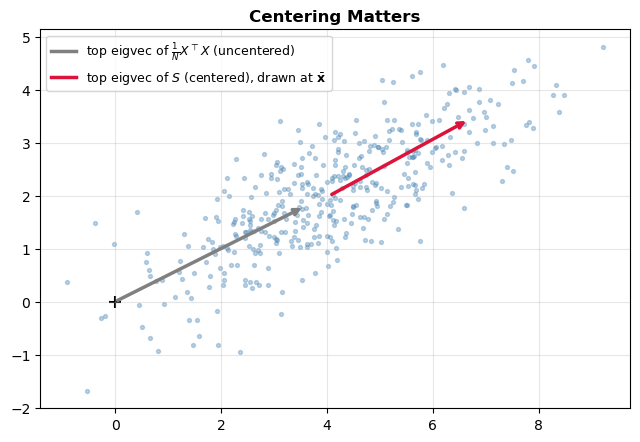

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 400
mean_true = np.array([4.0, 2.0])
cov_true = np.array([[3.0, 1.6],
                     [1.6, 1.4]])
X2 = rng.multivariate_normal(mean_true, cov_true, size=N)   # used again in Sections 4-6 and 12

x_bar = X2.mean(axis=0)
X2c = X2 - x_bar
S = X2c.T @ X2c / N

print("x_bar            :", np.round(x_bar, 4))
print("S = Xc^T Xc / N  :\n", np.round(S, 4))
print("matches np.cov(bias=True):", np.allclose(S, np.cov(X2.T, bias=True)))
print("symmetric:", np.allclose(S, S.T), "| eigenvalues >= 0:", np.linalg.eigvalsh(S))

# Check the identity Var(u^T x) = u^T S u for a random unit vector
u = rng.normal(size=2); u /= np.linalg.norm(u)
print(f"\nVar of projections = {np.var(X2 @ u):.6f}   u^T S u = {u @ S @ u:.6f}")

# Uncentered second-moment matrix: its top eigenvector points towards the mean
M2 = X2.T @ X2 / N
_, V_unc = np.linalg.eigh(M2)
_, V_c = np.linalg.eigh(S)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(X2[:, 0], X2[:, 1], s=8, alpha=0.35, color="steelblue")
ax.annotate("", xy=4 * V_unc[:, -1] * np.sign(V_unc[0, -1]), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="gray", lw=2.5))
ax.annotate("", xy=x_bar + 3 * V_c[:, -1] * np.sign(V_c[0, -1]), xytext=x_bar,
            arrowprops=dict(arrowstyle="->", color="crimson", lw=2.5))
ax.plot([], [], color="gray", lw=2.5, label=r"top eigvec of $\frac{1}{N}X^\top X$ (uncentered)")
ax.plot([], [], color="crimson", lw=2.5, label=r"top eigvec of $S$ (centered), drawn at $\bar{\mathbf{x}}$")
ax.scatter(0, 0, color="k", marker="+", s=80)
ax.set_aspect("equal"); ax.legend(fontsize=9, loc="upper left"); ax.grid(alpha=0.3)
ax.set_title("Centering Matters", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. PCA as Maximum Variance

**(Hotelling, 1933; Bishop §12.1.1.)** Find the unit direction $\mathbf u_1$ along which the projected data has the largest variance. By Section 3 this is the constrained problem

$$
\max_{\mathbf u_1\in\mathbb R^D}\ \mathbf u_1^\top S\,\mathbf u_1\qquad\text{s.t.}\qquad\mathbf u_1^\top\mathbf u_1=1 .
$$

The constraint is essential: without it $\mathbf u_1^\top S\mathbf u_1$ is unbounded ($\mathbf u_1\to c\,\mathbf u_1$ scales it by $c^2$). Introduce a **Lagrange multiplier** $\lambda_1$:

$$
\mathcal L(\mathbf u_1,\lambda_1)=\mathbf u_1^\top S\,\mathbf u_1+\lambda_1\big(1-\mathbf u_1^\top\mathbf u_1\big).
$$

Using $\nabla_{\mathbf u}(\mathbf u^\top S\mathbf u)=2S\mathbf u$ (as $S$ is symmetric) and setting the gradient to zero:

$$
\nabla_{\mathbf u_1}\mathcal L=2S\mathbf u_1-2\lambda_1\mathbf u_1=\mathbf 0
\quad\Longrightarrow\quad
\boxed{\;S\,\mathbf u_1=\lambda_1\mathbf u_1\;}
$$

So every stationary point is an **eigenvector** of $S$. Which one? Left-multiplying by $\mathbf u_1^\top$ and using $\mathbf u_1^\top\mathbf u_1=1$:

$$
\mathbf u_1^\top S\mathbf u_1=\lambda_1 ,
$$

i.e. **the variance along an eigenvector is its eigenvalue**. The maximum is attained at the eigenvector with the **largest** eigenvalue: this is the **first principal component**.

### More components

The second component maximizes the variance among unit directions **orthogonal** to $\mathbf u_1$. With multipliers $\lambda_2$ (norm) and $\eta$ (orthogonality):
$\nabla=2S\mathbf u_2-2\lambda_2\mathbf u_2-\eta\,\mathbf u_1=\mathbf 0$. Left-multiplying by $\mathbf u_1^\top$ gives $2\mathbf u_1^\top S\mathbf u_2-\eta=2\lambda_1\mathbf u_1^\top\mathbf u_2-\eta=-\eta=0$, so again $S\mathbf u_2=\lambda_2\mathbf u_2$, and the best choice is the eigenvector with the **second largest** eigenvalue. By induction (Bishop Ex. 12.1):

> **The $k$-dimensional subspace that maximizes the projected variance is spanned by the $k$ eigenvectors $\mathbf u_1,\dots,\mathbf u_k$ of $S$ with the largest eigenvalues $\lambda_1\ge\dots\ge\lambda_k$, and the retained variance is $\sum_{i=1}^k\lambda_i$.**

Equivalently, in matrix form: $\max_{B^\top B=I_k}\operatorname{tr}(B^\top SB)=\sum_{i\le k}\lambda_i$, attained at $B=U_k=[\mathbf u_1|\cdots|\mathbf u_k]$ (Ky Fan's theorem). Note the solution is a **subspace**: any $B=U_kR$ with $R$ orthogonal $k\times k$ gives the same trace — a rotational ambiguity that will reappear in PPCA (Section 11).

The **projection** of a point is $\mathbf z_n=U_k^\top(\mathbf x_n-\bar{\mathbf x})\in\mathbb R^k$ (the *scores* / *codes*), whose coordinates are uncorrelated with variances $\lambda_1,\dots,\lambda_k$.

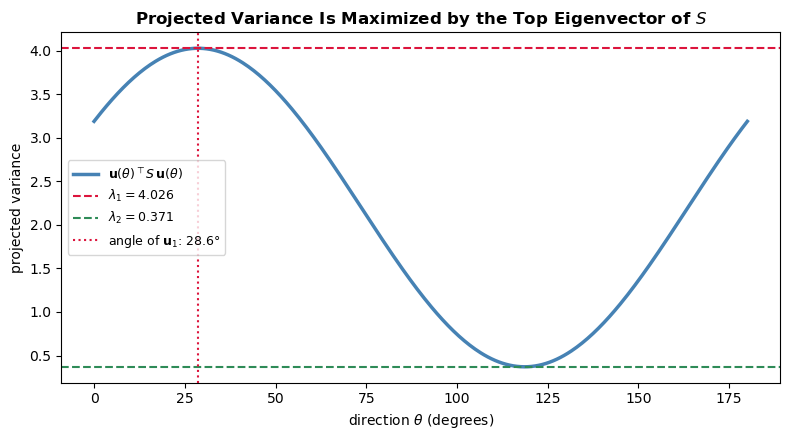

max over the grid  : 4.02598  at 28.5°
largest eigenvalue : 4.02600  at 28.6°
min over the grid  : 0.37112  | smallest eigenvalue: 0.37111


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Variance of the projections onto u(theta) = (cos theta, sin theta), on the 2D data of Section 3
thetas = np.linspace(0, np.pi, 361)
U_theta = np.stack([np.cos(thetas), np.sin(thetas)])            # (2, 361) unit vectors
proj_var = np.einsum("in,ij,jn->n", U_theta, S, U_theta)       # u^T S u for every theta

lam, U = np.linalg.eigh(S)                                    # ascending
theta_star = np.arctan2(U[1, -1], U[0, -1]) % np.pi

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.degrees(thetas), proj_var, lw=2.5, color="steelblue", label=r"$\mathbf{u}(\theta)^\top S\,\mathbf{u}(\theta)$")
ax.axhline(lam[-1], color="crimson", ls="--", label=fr"$\lambda_1={lam[-1]:.3f}$")
ax.axhline(lam[0], color="seagreen", ls="--", label=fr"$\lambda_2={lam[0]:.3f}$")
ax.axvline(np.degrees(theta_star), color="crimson", ls=":", lw=1.5, label=fr"angle of $\mathbf{{u}}_1$: {np.degrees(theta_star):.1f}°")
ax.set_xlabel(r"direction $\theta$ (degrees)"); ax.set_ylabel("projected variance")
ax.set_title("Projected Variance Is Maximized by the Top Eigenvector of $S$", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"max over the grid  : {proj_var.max():.5f}  at {np.degrees(thetas[proj_var.argmax()]):.1f}°")
print(f"largest eigenvalue : {lam[-1]:.5f}  at {np.degrees(theta_star):.1f}°")
print(f"min over the grid  : {proj_var.min():.5f}  | smallest eigenvalue: {lam[0]:.5f}")

---
## 5. PCA as Minimum Reconstruction Error

**(Pearson, 1901; Bishop §12.1.2; Deisenroth §10.3.)** A different question: among all $k$-dimensional affine subspaces, which one lets us **reconstruct** the data with the smallest squared error?

Take a complete orthonormal basis $\{\mathbf u_i\}_{i=1}^D$ of $\mathbb R^D$. Every point can be written exactly as $\mathbf x_n=\sum_{i=1}^D(\mathbf x_n^\top\mathbf u_i)\,\mathbf u_i$. We approximate it using only $k$ "free" coordinates per point plus $D-k$ coordinates **shared** by all points:

$$
\tilde{\mathbf x}_n=\sum_{i=1}^k z_{ni}\,\mathbf u_i+\sum_{i=k+1}^D b_i\,\mathbf u_i,
\qquad
J=\frac1N\sum_{n=1}^N\lVert\mathbf x_n-\tilde{\mathbf x}_n\rVert^2 .
$$

**Step 1 — optimal coordinates.** Minimizing $J$ w.r.t. $z_{nj}$ and $b_j$ (orthonormality makes the problem separable):

$$
\frac{\partial J}{\partial z_{nj}}=0\ \Rightarrow\ z_{nj}=\mathbf x_n^\top\mathbf u_j,
\qquad
\frac{\partial J}{\partial b_j}=0\ \Rightarrow\ b_j=\bar{\mathbf x}^\top\mathbf u_j .
$$

The free coordinates are the orthogonal projections of Section 2, and the shared ones are those of the mean. Substituting, the residual lives **entirely in the discarded directions**:

$$
\mathbf x_n-\tilde{\mathbf x}_n=\sum_{i=k+1}^D\big\{(\mathbf x_n-\bar{\mathbf x})^\top\mathbf u_i\big\}\,\mathbf u_i
\quad\Longrightarrow\quad
J=\frac1N\sum_{n=1}^N\sum_{i=k+1}^D\big((\mathbf x_n-\bar{\mathbf x})^\top\mathbf u_i\big)^2=\sum_{i=k+1}^D\mathbf u_i^\top S\,\mathbf u_i .
$$

**Step 2 — optimal basis.** Minimizing $\sum_{i>k}\mathbf u_i^\top S\mathbf u_i$ under $\mathbf u_i^\top\mathbf u_i=1$ is the Lagrangian problem of Section 4 with a $\min$ instead of a $\max$: the stationary points are eigenvectors, and the minimum is achieved by choosing as *discarded* directions the eigenvectors with the **smallest** eigenvalues:

$$
\boxed{\;J_{\min}=\sum_{i=k+1}^D\lambda_i\;}
$$

### Why the two views are the same

For each centered point Pythagoras gives $\lVert\mathbf x_n-\bar{\mathbf x}\rVert^2=\lVert\text{projection}\rVert^2+\lVert\text{residual}\rVert^2$. Averaging over $n$:

$$
\underbrace{\operatorname{tr}(S)=\sum_{i=1}^D\lambda_i}_{\text{total variance (fixed)}}
=\underbrace{\sum_{i=1}^k\lambda_i}_{\text{retained variance}}
+\underbrace{\sum_{i=k+1}^D\lambda_i}_{\text{reconstruction error }J}.
$$

The total is a constant of the data, so **maximizing the retained variance is identical to minimizing the reconstruction error**. In matrix form the reconstruction is $\tilde{\mathbf x}_n=\bar{\mathbf x}+U_kU_k^\top(\mathbf x_n-\bar{\mathbf x})$: encode with $U_k^\top$, decode with $U_k$, i.e. a **linear autoencoder** whose optimal weights span the principal subspace.

In [5]:
import numpy as np

# Numerical check on the 2D data: J(theta) + retained variance(theta) = tr(S) for every direction
recon_err = []
for th in thetas:
    u = np.array([np.cos(th), np.sin(th)])
    X_rec = x_bar + np.outer(X2c @ u, u)            # k = 1 reconstruction along u
    recon_err.append(np.mean(np.sum((X2 - X_rec) ** 2, axis=1)))
recon_err = np.array(recon_err)

print(f"tr(S)                                  = {np.trace(S):.6f}")
print(f"max_theta |retained + J - tr(S)|       = {np.max(np.abs(proj_var + recon_err - np.trace(S))):.2e}")
print(f"argmax retained variance (deg)         = {np.degrees(thetas[proj_var.argmax()]):.1f}")
print(f"argmin reconstruction error (deg)      = {np.degrees(thetas[recon_err.argmin()]):.1f}")
print(f"min J = {recon_err.min():.5f}   vs   discarded eigenvalue lambda_2 = {lam[0]:.5f}")

tr(S)                                  = 4.397108
max_theta |retained + J - tr(S)|       = 2.66e-15
argmax retained variance (deg)         = 28.5
argmin reconstruction error (deg)      = 28.5
min J = 0.37112   vs   discarded eigenvalue lambda_2 = 0.37111


---
## 6. Implementation From Scratch: PCA on a 2D Dataset

The derivations translate directly into an algorithm:

1. $\bar{\mathbf x}\leftarrow\frac1N\sum_n\mathbf x_n$, $\;X_c\leftarrow X-\mathbf 1\bar{\mathbf x}^\top$
2. $S\leftarrow\frac1N X_c^\top X_c$
3. $(\boldsymbol\lambda,U)\leftarrow$ `np.linalg.eigh(S)` — the right tool for **symmetric** matrices: guaranteed real eigenvalues and orthonormal eigenvectors, returned in **ascending** order (so we reverse them).
4. Keep $U_k$ (first $k$ columns). **Encode** $Z=X_cU_k$, **decode** $\tilde X=ZU_k^\top+\mathbf 1\bar{\mathbf x}^\top$.

Eigenvectors are defined only up to sign; we fix a deterministic convention (largest-magnitude entry positive) so results are reproducible.

eigenvalues  : [4.026  0.3711]
components   :
 [[ 0.8778 -0.479 ]
 [ 0.479   0.8778]]
U^T U = I    : True
Var(z) = 4.0260  (= lambda_1)
J = 0.3711  (= lambda_2)


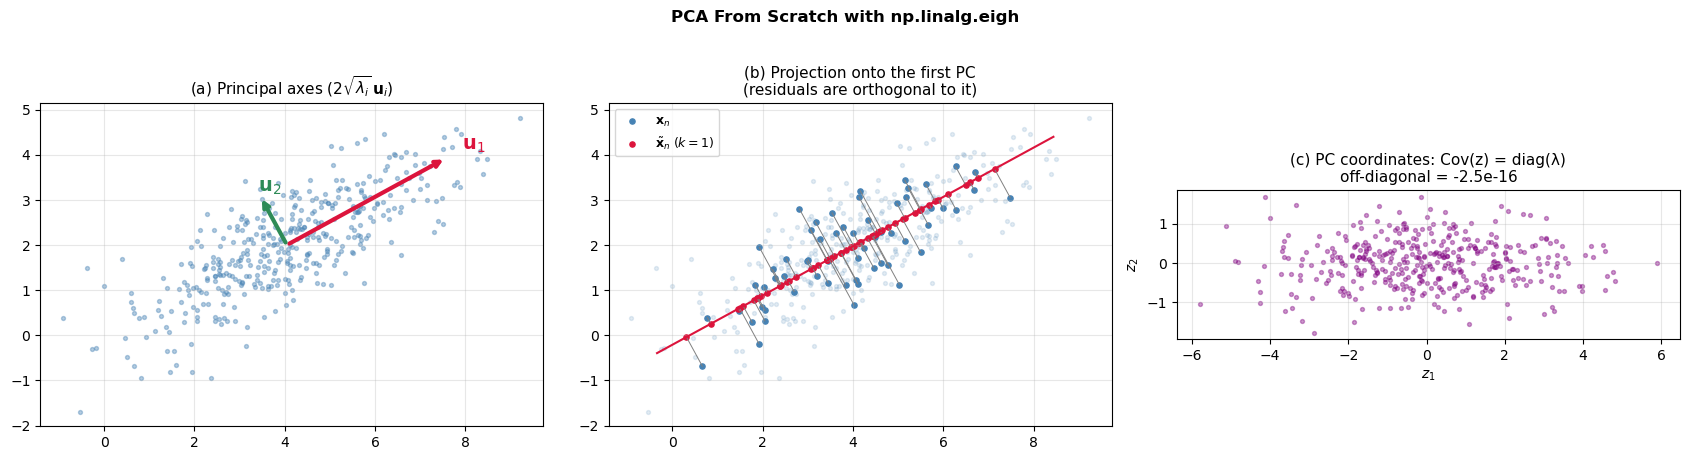

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def pca_fit(X, k):
    # PCA via eigendecomposition of S = Xc^T Xc / N.
    N, D = X.shape
    mean = X.mean(axis=0)
    Xc = X - mean
    S = Xc.T @ Xc / N
    eigvals, eigvecs = np.linalg.eigh(S)                  # ascending order
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    # sign convention: largest-|.| entry of each eigenvector is positive
    signs = np.sign(eigvecs[np.abs(eigvecs).argmax(axis=0), np.arange(D)])
    eigvecs = eigvecs * signs
    return {"mean": mean, "components": eigvecs[:, :k], "eigvals": eigvals, "all_components": eigvecs}

def pca_transform(model, X):
    return (X - model["mean"]) @ model["components"]

def pca_inverse_transform(model, Z):
    return Z @ model["components"].T + model["mean"]

pca2 = pca_fit(X2, k=1)
U2, lam2 = pca2["all_components"], pca2["eigvals"]
Z2 = pca_transform(pca2, X2)
X2_rec = pca_inverse_transform(pca2, Z2)

print("eigenvalues  :", np.round(lam2, 4))
print("components   :\n", np.round(U2, 4))
print("U^T U = I    :", np.allclose(U2.T @ U2, np.eye(2)))
print(f"Var(z) = {Z2.var():.4f}  (= lambda_1)")
print(f"J = {np.mean(np.sum((X2 - X2_rec) ** 2, axis=1)):.4f}  (= lambda_2)")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) data + principal axes scaled by 2*sqrt(lambda)
ax = axes[0]
ax.scatter(X2[:, 0], X2[:, 1], s=8, alpha=0.4, color="steelblue")
for i, c in enumerate(["crimson", "seagreen"]):
    v = U2[:, i] * 2 * np.sqrt(lam2[i])
    ax.annotate("", xy=x_bar + v, xytext=x_bar, arrowprops=dict(arrowstyle="->", color=c, lw=3))
    ax.text(*(x_bar + 1.1 * v), fr"$\mathbf{{u}}_{i+1}$", color=c, fontsize=14, fontweight="bold")
ax.set_title(r"(a) Principal axes ($2\sqrt{\lambda_i}\,\mathbf{u}_i$)", fontsize=11)
ax.set_aspect("equal"); ax.grid(alpha=0.3)

# (b) orthogonal projection onto the first principal line
ax = axes[1]
idx = np.random.default_rng(3).choice(len(X2), 60, replace=False)
ax.scatter(X2[:, 0], X2[:, 1], s=8, alpha=0.15, color="steelblue")
ax.scatter(X2[idx, 0], X2[idx, 1], s=14, color="steelblue", label=r"$\mathbf{x}_n$")
ax.scatter(X2_rec[idx, 0], X2_rec[idx, 1], s=14, color="crimson", label=r"$\tilde{\mathbf{x}}_n$ ($k=1$)")
for a, r in zip(X2[idx], X2_rec[idx]):
    ax.plot([a[0], r[0]], [a[1], r[1]], color="gray", lw=0.7)
line = x_bar + np.outer(np.linspace(-5, 5, 2), U2[:, 0])
ax.plot(line[:, 0], line[:, 1], color="crimson", lw=1.5)
ax.set_title("(b) Projection onto the first PC\n(residuals are orthogonal to it)", fontsize=11)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=9)

# (c) data in PC coordinates: decorrelated
ax = axes[2]
Z_full = (X2 - x_bar) @ U2
ax.scatter(Z_full[:, 0], Z_full[:, 1], s=8, alpha=0.4, color="purple")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title(f"(c) PC coordinates: Cov(z) = diag(λ)\noff-diagonal = {np.cov(Z_full.T, bias=True)[0, 1]:.1e}", fontsize=11)
ax.set_aspect("equal"); ax.grid(alpha=0.3)

plt.suptitle("PCA From Scratch with np.linalg.eigh", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 7. Explained Variance and the Choice of $k$

Since $\lambda_i$ is the variance captured by component $i$, the natural diagnostics are

$$
\text{explained variance ratio}_i=\frac{\lambda_i}{\sum_{j=1}^D\lambda_j},
\qquad
\text{cumulative}(k)=\frac{\sum_{i=1}^k\lambda_i}{\sum_{j=1}^D\lambda_j}=1-\frac{J_{\min}(k)}{\operatorname{tr}(S)} .
$$

Common rules for choosing $k$:
- **Scree plot / elbow:** plot $\lambda_i$ against $i$ and cut where the curve flattens — beyond the elbow components capture roughly constant, noise-like variance.
- **Variance threshold:** smallest $k$ with cumulative$(k)\ge 90\%$ / $95\%$ / $99\%$.
- **Downstream performance:** treat $k$ as a hyperparameter and cross-validate the task that consumes the features.
- **Likelihood:** PCA alone has no likelihood, but its probabilistic version does (Section 11), so $k$ can be selected on held-out log-likelihood.

To see a clean elbow we generate $D=10$ dimensional data driven by only $k_{\text{true}}=3$ latent factors plus isotropic noise — this is exactly the generative model of PPCA (Section 10), so we will reuse this dataset there.

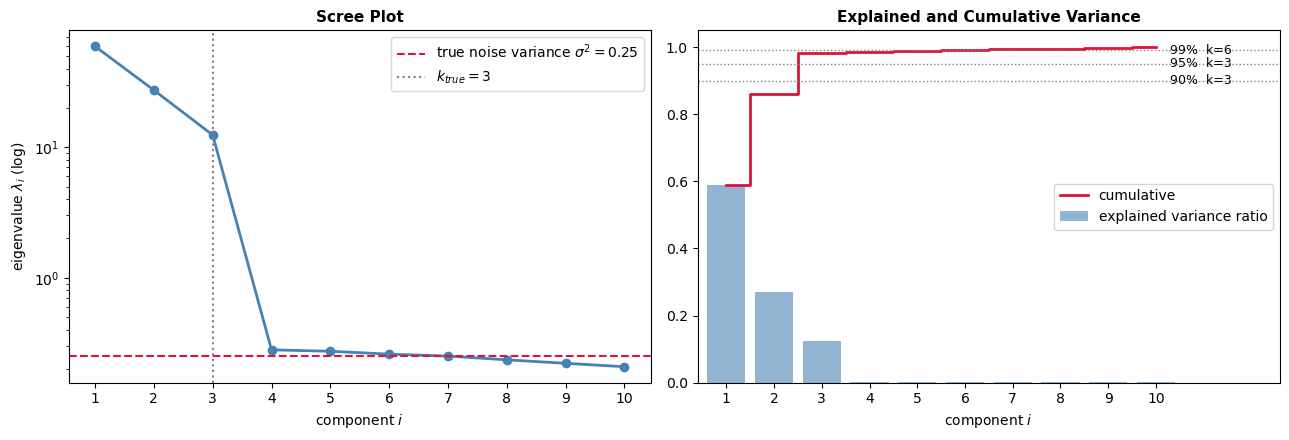

eigenvalues: [59.309 27.387 12.413  0.28   0.273  0.26   0.251  0.235  0.221  0.208]
mean of the 7 smallest eigenvalues = 0.2469  (true sigma^2 = 0.25)


In [7]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
D_syn, k_true, N_syn = 10, 3, 1000
W_true = rng.normal(size=(D_syn, k_true)) * np.array([3.0, 2.0, 1.2])
mu_true_syn = rng.normal(size=D_syn)
sigma2_true = 0.25
Z_lat = rng.normal(size=(N_syn, k_true))
X_syn = Z_lat @ W_true.T + mu_true_syn + np.sqrt(sigma2_true) * rng.normal(size=(N_syn, D_syn))

pca_syn = pca_fit(X_syn, k=D_syn)
lam_syn = pca_syn["eigvals"]
ratio = lam_syn / lam_syn.sum()
cum = np.cumsum(ratio)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
comp = np.arange(1, D_syn + 1)
axes[0].plot(comp, lam_syn, "o-", lw=2, color="steelblue")
axes[0].axhline(sigma2_true, color="crimson", ls="--", label=fr"true noise variance $\sigma^2={sigma2_true}$")
axes[0].axvline(k_true, color="gray", ls=":", label=fr"$k_{{true}}={k_true}$")
axes[0].set_yscale("log"); axes[0].set_xticks(comp)
axes[0].set_xlabel("component $i$"); axes[0].set_ylabel(r"eigenvalue $\lambda_i$ (log)")
axes[0].set_title("Scree Plot", fontsize=11, fontweight="bold"); axes[0].legend()

axes[1].bar(comp, ratio, color="steelblue", alpha=0.6, label="explained variance ratio")
axes[1].step(comp, cum, where="mid", color="crimson", lw=2, label="cumulative")
for thr in [0.9, 0.95, 0.99]:
    axes[1].axhline(thr, color="gray", ls=":", lw=1)
    axes[1].text(D_syn + 0.3, thr, f"{int(thr*100)}%  k={np.searchsorted(cum, thr) + 1}", va="center", fontsize=9)
axes[1].set_xticks(comp); axes[1].set_xlim(0.4, D_syn + 2.6); axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("component $i$")
axes[1].set_title("Explained and Cumulative Variance", fontsize=11, fontweight="bold"); axes[1].legend(loc="center right")
plt.tight_layout()
plt.show()

print("eigenvalues:", np.round(lam_syn, 3))
print(f"mean of the {D_syn - k_true} smallest eigenvalues = {lam_syn[k_true:].mean():.4f}  (true sigma^2 = {sigma2_true})")

The scree plot shows three large eigenvalues followed by a **flat floor** at $\approx\sigma^2$: the trailing directions only contain isotropic noise, whose variance is the same in every direction. Remember the number printed above — the *average of the discarded eigenvalues* — it is precisely the maximum-likelihood estimate of the noise variance in PPCA (Section 11).

---
## 8. PCA via the Singular Value Decomposition

Every matrix has a **singular value decomposition** (Deisenroth §4.5). For the centered data matrix $X_c\in\mathbb R^{N\times D}$:

$$
\boxed{\;X_c=U\Sigma V^\top\;}
\qquad U\in\mathbb R^{N\times N},\ V\in\mathbb R^{D\times D}\ \text{orthogonal},\ \Sigma=\operatorname{diag}(\sigma_1\ge\sigma_2\ge\dots\ge0).
$$

*(Careful with notation: in the SVD $U$ holds the **left** singular vectors in $\mathbb R^N$; the principal directions will be the columns of $V$.)* Plug it into the covariance:

$$
S=\frac1N X_c^\top X_c=\frac1N V\Sigma^\top U^\top U\Sigma V^\top=V\,\frac{\Sigma^\top\Sigma}{N}\,V^\top .
$$

This *is* an eigendecomposition of $S$ (orthogonal $V$, diagonal middle factor), so by uniqueness:

$$
\boxed{\;\text{principal directions}=\text{columns of }V,\qquad\lambda_i=\frac{\sigma_i^2}{N}\;}
$$

and the scores are $Z=X_cV_k=U_k\Sigma_k$ (the left singular vectors scaled by the singular values).

**Why SVD is the method used in practice** (it is what `sklearn.decomposition.PCA` does):
- **Numerical stability.** Forming $X_c^\top X_c$ squares the condition number, $\kappa(X_c^\top X_c)=\kappa(X_c)^2$: small eigenvalues lose relative precision. SVD works on $X_c$ directly.
- **Efficiency.** The thin SVD costs $O(ND\min(N,D))$, and truncated/randomized SVD computes just the top $k$ triplets. When $D\gg N$ one never needs the $D\times D$ matrix $S$ (Bishop §12.1.4).

**Eckart–Young theorem.** The truncated SVD $X_c^{(k)}=U_k\Sigma_kV_k^\top$ is the best rank-$k$ approximation of $X_c$ in Frobenius norm, with error $\lVert X_c-X_c^{(k)}\rVert_F^2=\sum_{i>k}\sigma_i^2=N\sum_{i>k}\lambda_i$ — exactly $N\cdot J_{\min}$ from Section 5. PCA reconstruction *is* low-rank matrix approximation.

In [8]:
import numpy as np

def pca_fit_svd(X, k):
    N = X.shape[0]
    mean = X.mean(axis=0)
    Xc = X - mean
    Usvd, sing, Vt = np.linalg.svd(Xc, full_matrices=False)   # thin SVD
    return {"mean": mean, "components": Vt[:k].T, "eigvals": sing ** 2 / N, "singular_values": sing, "U": Usvd}

svd_syn = pca_fit_svd(X_syn, k=D_syn)
Xc_syn = X_syn - X_syn.mean(axis=0)

print("lambda (eigh)        :", np.round(pca_syn["eigvals"], 5))
print("sigma^2 / N (SVD)    :", np.round(svd_syn["eigvals"], 5))
print("eigenvalues match    :", np.allclose(pca_syn["eigvals"], svd_syn["eigvals"]))
# eigenvectors agree up to sign: |<v_eigh, v_svd>| = 1
dots = np.abs(np.sum(pca_syn["all_components"] * svd_syn["components"], axis=0))
print("|<u_i, v_i>|         :", np.round(dots, 8))

# Scores: Xc V_k = U_k Sigma_k
k = 3
Vk = svd_syn["components"][:, :k]
print("Xc V_k == U_k S_k    :", np.allclose(Xc_syn @ Vk, svd_syn["U"][:, :k] * svd_syn["singular_values"][:k]))

# Eckart-Young: rank-k reconstruction error = sum of discarded sigma^2 = N * sum of discarded lambda
Xc_k = (svd_syn["U"][:, :k] * svd_syn["singular_values"][:k]) @ Vk.T
print(f"||Xc - Xc_k||_F^2 = {np.linalg.norm(Xc_syn - Xc_k, 'fro')**2:.4f}"
      f"   N * sum_(i>k) lambda_i = {N_syn * svd_syn['eigvals'][k:].sum():.4f}")

# Conditioning: forming Xc^T Xc squares the condition number
print(f"\ncond(Xc) = {np.linalg.cond(Xc_syn):.2f}   cond(Xc^T Xc) = {np.linalg.cond(Xc_syn.T @ Xc_syn):.2f}"
      f"   cond(Xc)^2 = {np.linalg.cond(Xc_syn)**2:.2f}")

lambda (eigh)        : [59.30926 27.38691 12.41285  0.28032  0.27322  0.25972  0.25103  0.23495
  0.22095  0.20808]
sigma^2 / N (SVD)    : [59.30926 27.38691 12.41285  0.28032  0.27322  0.25972  0.25103  0.23495
  0.22095  0.20808]
eigenvalues match    : True
|<u_i, v_i>|         : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Xc V_k == U_k S_k    : True
||Xc - Xc_k||_F^2 = 1728.2760   N * sum_(i>k) lambda_i = 1728.2760

cond(Xc) = 16.88   cond(Xc^T Xc) = 285.03   cond(Xc)^2 = 285.03


---
## 9. Real Example: Compressing Handwritten Digits

`sklearn.datasets.load_digits` contains $N=1797$ grayscale $8\times8$ images of digits $0$–$9$, i.e. points in $\mathbb R^{64}$. Many pixels are redundant (the border is almost always black, neighbouring pixels are correlated), so we expect a small number of components to capture most of the variance. We use the from-scratch SVD implementation of Section 8 and look at:

1. the spectrum and how many components are needed for a given fraction of variance;
2. the **mean image** and the first **eigen-digits** (principal directions reshaped as images);
3. the 2D embedding $(z_1,z_2)$ coloured by class — PCA is *unsupervised*, labels are used only for colouring;
4. reconstructions $\tilde{\mathbf x}=\bar{\mathbf x}+U_kU_k^\top(\mathbf x-\bar{\mathbf x})$ for increasing $k$, and the check that the mean reconstruction error equals $\sum_{i>k}\lambda_i$.

 50% of variance -> k =  5  (out of 64)
 80% of variance -> k = 13  (out of 64)
 90% of variance -> k = 21  (out of 64)
 95% of variance -> k = 29  (out of 64)
 99% of variance -> k = 41  (out of 64)


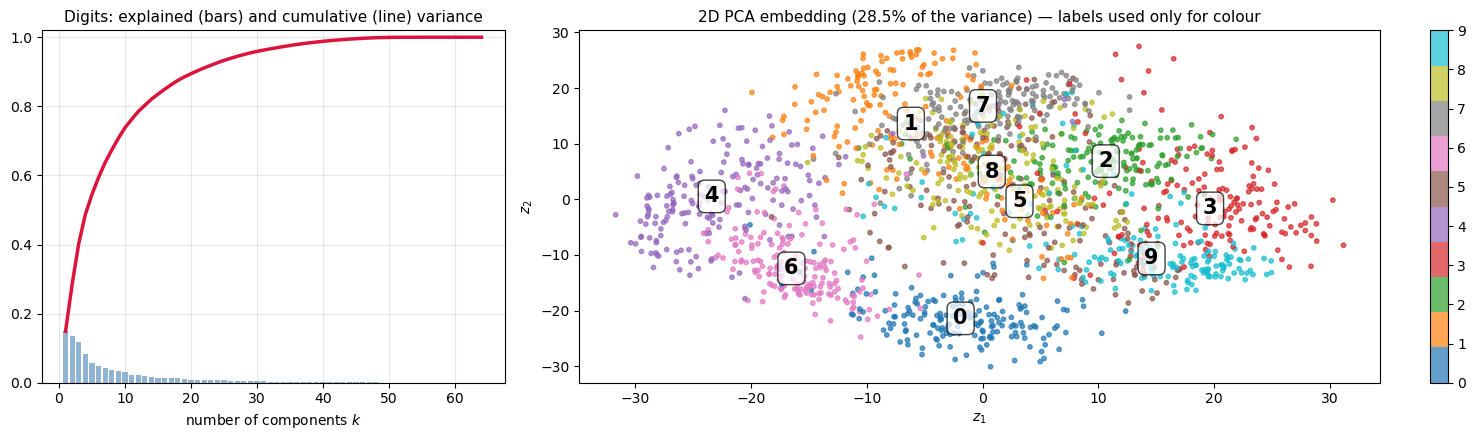

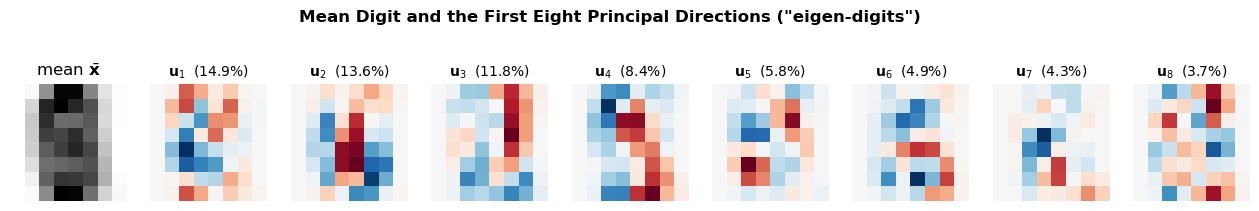

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
X_dig, y_dig = digits.data, digits.target          # (1797, 64), pixel values in [0, 16]
N_dig, D_dig = X_dig.shape

pca_dig = pca_fit_svd(X_dig, k=D_dig)
lam_dig = pca_dig["eigvals"]
cum_dig = np.cumsum(lam_dig) / lam_dig.sum()
for thr in [0.5, 0.8, 0.9, 0.95, 0.99]:
    print(f"{int(thr*100):>3d}% of variance -> k = {np.searchsorted(cum_dig, thr) + 1:>2d}  (out of {D_dig})")

fig = plt.figure(figsize=(16, 4.5))
ax = fig.add_subplot(1, 3, 1)
ax.plot(np.arange(1, D_dig + 1), cum_dig, lw=2.5, color="crimson")
ax.bar(np.arange(1, D_dig + 1), lam_dig / lam_dig.sum(), color="steelblue", alpha=0.6)
ax.set_xlabel("number of components $k$"); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
ax.set_title("Digits: explained (bars) and cumulative (line) variance", fontsize=11)

ax = fig.add_subplot(1, 3, (2, 3))
Z_dig = (X_dig - pca_dig["mean"]) @ pca_dig["components"][:, :2]
sc = ax.scatter(Z_dig[:, 0], Z_dig[:, 1], c=y_dig, cmap="tab10", s=10, alpha=0.7)
for d in range(10):
    ax.text(*np.median(Z_dig[y_dig == d], axis=0), str(d), fontsize=15, fontweight="bold",
            ha="center", va="center", bbox=dict(boxstyle="round", fc="white", alpha=0.75))
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title(f"2D PCA embedding ({cum_dig[1]*100:.1f}% of the variance) — labels used only for colour", fontsize=11)
plt.colorbar(sc, ax=ax, ticks=range(10))
plt.tight_layout()
plt.show()

# Mean image and first eigen-digits
fig, axes = plt.subplots(1, 9, figsize=(16, 2.4))
axes[0].imshow(pca_dig["mean"].reshape(8, 8), cmap="gray_r"); axes[0].set_title(r"mean $\bar{\mathbf{x}}$")
for i in range(8):
    v = pca_dig["components"][:, i].reshape(8, 8)
    vmax = np.abs(v).max()
    axes[i + 1].imshow(v, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[i + 1].set_title(fr"$\mathbf{{u}}_{i+1}$  ({lam_dig[i]/lam_dig.sum()*100:.1f}%)", fontsize=10)
for a in axes: a.axis("off")
plt.suptitle("Mean Digit and the First Eight Principal Directions (\"eigen-digits\")", fontsize=12, fontweight="bold", y=1.05)
plt.show()

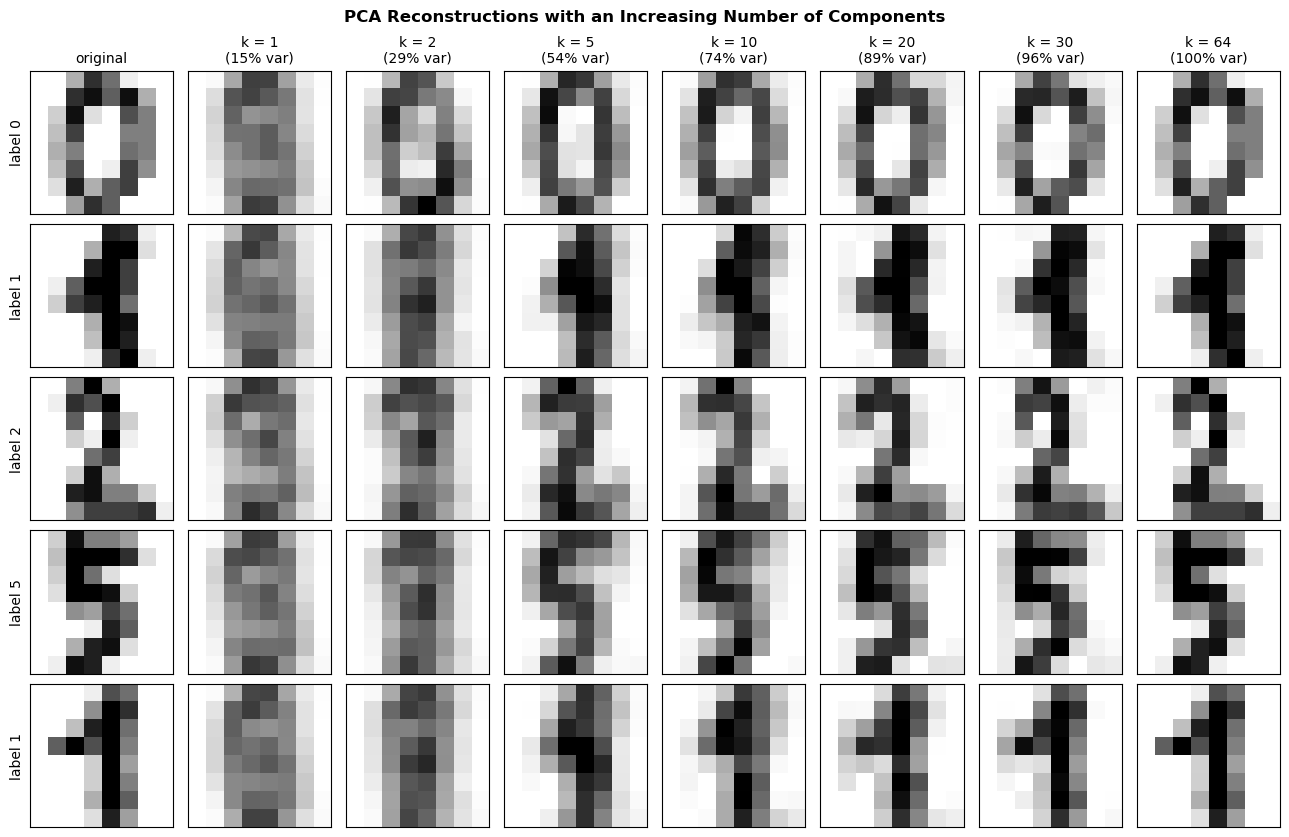

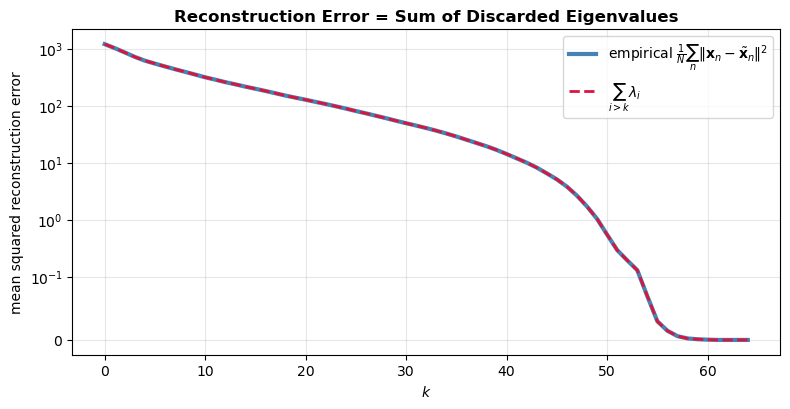

max |empirical - theory| over k: 5.684341886080801e-13
k=20: store 37284 numbers instead of 115008  (ratio 3.1x) keeping 89.4% of the variance


In [10]:
import numpy as np
import matplotlib.pyplot as plt

ks = [1, 2, 5, 10, 20, 30, 64]
examples = [0, 11, 22, 35, 47]                 # a few test images
fig, axes = plt.subplots(len(examples), len(ks) + 1, figsize=(13, 8.5))
for r, n in enumerate(examples):
    axes[r, 0].imshow(X_dig[n].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    axes[r, 0].set_ylabel(f"label {y_dig[n]}")
    for c, k in enumerate(ks):
        Uk = pca_dig["components"][:, :k]
        x_rec = pca_dig["mean"] + Uk @ (Uk.T @ (X_dig[n] - pca_dig["mean"]))
        axes[r, c + 1].imshow(x_rec.reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
        if r == 0:
            axes[r, c + 1].set_title(f"k = {k}\n({cum_dig[k-1]*100:.0f}% var)", fontsize=10)
axes[0, 0].set_title("original", fontsize=10)
for a in axes.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.suptitle("PCA Reconstructions with an Increasing Number of Components", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Reconstruction error vs k: empirical MSE equals the sum of discarded eigenvalues
Xc_dig = X_dig - pca_dig["mean"]
emp_err, theo_err = [], []
for k in range(0, D_dig + 1):
    Uk = pca_dig["components"][:, :k]
    rec = Xc_dig @ Uk @ Uk.T
    emp_err.append(np.mean(np.sum((Xc_dig - rec) ** 2, axis=1)))
    theo_err.append(lam_dig[k:].sum())

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(range(D_dig + 1), emp_err, lw=3, color="steelblue", label=r"empirical $\frac{1}{N}\sum_n\|\mathbf{x}_n-\tilde{\mathbf{x}}_n\|^2$")
ax.plot(range(D_dig + 1), theo_err, "--", lw=2, color="crimson", label=r"$\sum_{i>k}\lambda_i$")
ax.set_xlabel("$k$"); ax.set_ylabel("mean squared reconstruction error")
ax.set_yscale("symlog", linthresh=1e-1); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Reconstruction Error = Sum of Discarded Eigenvalues", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print("max |empirical - theory| over k:", np.max(np.abs(np.array(emp_err) - np.array(theo_err))))

# Compression ratio for k = 20
k = 20
stored = N_dig * k + D_dig * k + D_dig
print(f"k={k}: store {stored} numbers instead of {N_dig * D_dig}  "
      f"(ratio {N_dig * D_dig / stored:.1f}x) keeping {cum_dig[k-1]*100:.1f}% of the variance")

---
## 10. Probabilistic PCA I: The Generative Model

Classical PCA is a geometric procedure: it has no density, no likelihood, no notion of noise. **Probabilistic PCA** (Tipping & Bishop, 1999; Bishop §12.2) recasts it as the maximum-likelihood solution of a **linear-Gaussian latent-variable model**. This buys us: a density $p(\mathbf x)$ (for anomaly detection, model comparison, choosing $k$), a principled treatment of noise, the ability to handle missing data via EM, and a building block for mixtures of PPCA and Bayesian PCA.

### Generative story

A low-dimensional latent variable $\mathbf z\in\mathbb R^k$ is mapped linearly into $\mathbb R^D$ and corrupted by isotropic noise:

$$
\boxed{\;
\mathbf z\sim\mathcal N(\mathbf 0,I_k),\qquad
\mathbf x=W\mathbf z+\boldsymbol\mu+\boldsymbol\varepsilon,\qquad
\boldsymbol\varepsilon\sim\mathcal N(\mathbf 0,\sigma^2I_D)\;}
$$

with $W\in\mathbb R^{D\times k}$, $\boldsymbol\mu\in\mathbb R^D$, $\sigma^2>0$, and $\boldsymbol\varepsilon$ independent of $\mathbf z$. Equivalently $p(\mathbf x\mid\mathbf z)=\mathcal N(\mathbf x\mid W\mathbf z+\boldsymbol\mu,\ \sigma^2I)$. Compare with the GMM of `05_gaussian_mixture_models`: there the latent variable is **discrete** (which cluster); here it is **continuous** (coordinates on a $k$-dimensional plane).

### The marginal distribution

$$
p(\mathbf x)=\int p(\mathbf x\mid\mathbf z)\,p(\mathbf z)\,d\mathbf z=\mathcal N(\mathbf x\mid\boldsymbol\mu,\ C),
\qquad
\boxed{\;C=WW^\top+\sigma^2I_D\;}
$$

> **Exercise.** Derive this result before opening the solution. *Hint:* $\mathbf x$ is an affine function of the jointly Gaussian vector $(\mathbf z,\boldsymbol\varepsilon)$, so it is Gaussian; you only need its mean and covariance.

<details>
<summary><b>Solution</b> (click to expand)</summary>

Since $(\mathbf z,\boldsymbol\varepsilon)$ is jointly Gaussian (independent Gaussians) and $\mathbf x=W\mathbf z+\boldsymbol\varepsilon+\boldsymbol\mu$ is affine in it, $\mathbf x$ is Gaussian and is fully specified by its first two moments:

$$
\mathbb E[\mathbf x]=W\,\mathbb E[\mathbf z]+\boldsymbol\mu+\mathbb E[\boldsymbol\varepsilon]=\boldsymbol\mu ,
$$

$$
\operatorname{Cov}[\mathbf x]=\mathbb E\big[(W\mathbf z+\boldsymbol\varepsilon)(W\mathbf z+\boldsymbol\varepsilon)^\top\big]
=W\underbrace{\mathbb E[\mathbf z\mathbf z^\top]}_{I_k}W^\top+W\underbrace{\mathbb E[\mathbf z\boldsymbol\varepsilon^\top]}_{\mathbf 0}+\underbrace{\mathbb E[\boldsymbol\varepsilon\mathbf z^\top]}_{\mathbf 0}W^\top+\underbrace{\mathbb E[\boldsymbol\varepsilon\boldsymbol\varepsilon^\top]}_{\sigma^2I_D}
=WW^\top+\sigma^2I_D .
$$

The cross terms vanish because $\mathbf z\perp\boldsymbol\varepsilon$ and both have zero mean. Alternatively, apply the linear-Gaussian marginalization formula (Bishop eq. 2.115) with $p(\mathbf z)=\mathcal N(\mathbf 0,I)$, $p(\mathbf x\mid\mathbf z)=\mathcal N(W\mathbf z+\boldsymbol\mu,\sigma^2I)$.
</details>

**Reading $C$.** Along any direction $\mathbf v\perp\operatorname{col}(W)$ the variance is $\mathbf v^\top C\mathbf v=\sigma^2$ (noise only); along the columns of $W$ it is larger. So PPCA is a Gaussian whose covariance is "**$\sigma^2$ everywhere, plus a rank-$k$ boost**" — it needs $Dk+1-k(k-1)/2$ parameters instead of the $D(D+1)/2$ of a full covariance, interpolating between an isotropic and a full Gaussian.

**Rotational non-identifiability.** For any orthogonal $R\in\mathbb R^{k\times k}$, $\widetilde W=WR$ gives $\widetilde W\widetilde W^\top=WRR^\top W^\top=WW^\top$: the same $C$, hence the same density. The model identifies the **subspace**, not a particular basis of it — exactly as in Section 4.

**Efficient evaluation.** Inverting the $D\times D$ matrix $C$ reduces to a $k\times k$ inversion via the Woodbury identity, with $M:=W^\top W+\sigma^2I_k\in\mathbb R^{k\times k}$:

$$
C^{-1}=\sigma^{-2}\big(I_D-WM^{-1}W^\top\big),\qquad \ln|C|=(D-k)\ln\sigma^2+\ln|M| .
$$

In [11]:
import numpy as np

# Monte-Carlo check of the marginal: sample from the generative model, compare the
# empirical covariance with C = W W^T + sigma^2 I  (true parameters of Section 7)
rng = np.random.default_rng(11)
n_mc = 200_000
z = rng.normal(size=(n_mc, k_true))
eps = np.sqrt(sigma2_true) * rng.normal(size=(n_mc, D_syn))
x = z @ W_true.T + mu_true_syn + eps

C_true = W_true @ W_true.T + sigma2_true * np.eye(D_syn)
C_emp = np.cov(x.T, bias=True)
print(f"max |C_emp - C| / max |C| = {np.abs(C_emp - C_true).max() / np.abs(C_true).max():.4f}")
print(f"max |mean_emp - mu|       = {np.abs(x.mean(axis=0) - mu_true_syn).max():.4f}")

# Rotational invariance: W R gives the same C
theta = 0.7
R = np.eye(k_true)
R[:2, :2] = [[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]
print("C(W R) == C(W)            :", np.allclose((W_true @ R) @ (W_true @ R).T + sigma2_true * np.eye(D_syn), C_true))

# Woodbury: C^{-1} = (I - W M^{-1} W^T) / sigma^2,  log|C| = (D-k) log sigma^2 + log|M|
M = W_true.T @ W_true + sigma2_true * np.eye(k_true)
C_inv_wood = (np.eye(D_syn) - W_true @ np.linalg.solve(M, W_true.T)) / sigma2_true
print("Woodbury inverse correct  :", np.allclose(C_inv_wood, np.linalg.inv(C_true)))
print("log-det identity correct  :", np.isclose((D_syn - k_true) * np.log(sigma2_true) + np.linalg.slogdet(M)[1],
                                               np.linalg.slogdet(C_true)[1]))

max |C_emp - C| / max |C| = 0.0047
max |mean_emp - mu|       = 0.0145
C(W R) == C(W)            : True
Woodbury inverse correct  : True
log-det identity correct  : True


---
## 11. Probabilistic PCA II: Closed-Form Maximum Likelihood

Given i.i.d. data, since $p(\mathbf x)=\mathcal N(\boldsymbol\mu,C)$ the log-likelihood is (Bishop eq. 12.44)

$$
\ln p(X\mid\boldsymbol\mu,W,\sigma^2)=-\frac N2\Big\{D\ln(2\pi)+\ln|C|+\operatorname{tr}\big(C^{-1}S\big)\Big\},
$$

after substituting $\boldsymbol\mu_{ML}=\bar{\mathbf x}$ (the usual Gaussian result; $S$ is the sample covariance of Section 3). The data enter only through $S$ — PPCA is a structured fit of a Gaussian covariance to $S$.

Remarkably, unlike the GMM, the maximization over $W$ and $\sigma^2$ has a **closed form** (Tipping & Bishop, 1999). Let $S=U\Lambda U^\top$ with $\lambda_1\ge\dots\ge\lambda_D$, $U_k$ the top-$k$ eigenvectors and $\Lambda_k=\operatorname{diag}(\lambda_1,\dots,\lambda_k)$:

$$
\boxed{\;
\sigma^2_{ML}=\frac{1}{D-k}\sum_{i=k+1}^D\lambda_i,
\qquad
W_{ML}=U_k\big(\Lambda_k-\sigma^2_{ML}I_k\big)^{1/2}R\;}
$$

with $R$ an **arbitrary** $k\times k$ orthogonal matrix (the rotational ambiguity of Section 10).

**Sketch of why.** Setting $\partial/\partial W=0$ gives the stationarity condition $S\,C^{-1}W=W$. Writing the SVD $W=L\,\Delta\,R^\top$, this forces each column of $L$ to be an eigenvector $\mathbf u_i$ of $S$ with $\delta_i^2=\lambda_i-\sigma^2$ (or $\delta_i=0$). Then $\sigma^2$ is obtained from $\partial/\partial\sigma^2=0$, and comparing likelihoods shows the **global** maximum keeps the $k$ **largest** eigenvalues — all other stationary points are saddles. Full proof in Tipping & Bishop (1999), §3.2.

**Interpretation.** Plugging $W_{ML}$ back in:

$$
C_{ML}=U_k(\Lambda_k-\sigma^2_{ML}I)U_k^\top+\sigma^2_{ML}I
\;\Longrightarrow\;
\mathbf u_i^\top C_{ML}\,\mathbf u_i=
\begin{cases}\lambda_i & i\le k\ \ (\text{retained: variance reproduced exactly})\\[2pt] \sigma^2_{ML} & i>k\ \ (\text{discarded: replaced by their average})\end{cases}
$$

- The columns of $W_{ML}$ span the **principal subspace**: PPCA's MLE recovers classical PCA.
- $\sigma^2_{ML}$ is the **average variance lost** in the discarded directions — the noise floor we saw in the scree plot of Section 7.
- Each column is scaled by $\sqrt{\lambda_i-\sigma^2}$: the variance along $\mathbf u_i$ is split between the latent part ($\lambda_i-\sigma^2$) and the noise ($\sigma^2$).

> **EM for PPCA.** The likelihood can also be maximized by the EM algorithm (Bishop §12.2.2), treating $\mathbf z_n$ as missing data. It never forms $S$ (cost $O(NDk)$ per iteration), handles missing entries in $X$ naturally, and as $\sigma^2\to0$ becomes an iterative PCA solver. We do not develop it here: EM is derived in full generality in `05_gaussian_mixture_models` (§6–9), and its PPCA version follows the same E-step / M-step template with Gaussian instead of categorical latents.

sigma^2_ML = 0.2469   (true sigma^2 = 0.25)
u_i^T C_ML u_i : [59.3093 27.3869 12.4128  0.2469  0.2469  0.2469  0.2469  0.2469  0.2469
  0.2469]
lambda_i       : [59.3093 27.3869 12.4128  0.2803  0.2732  0.2597  0.251   0.235   0.2209
  0.2081]
span(W_ML) == span(U_k): True
||P_ML - P_true||_F = 0.0169
loglik(W_ML) = -14.249416   loglik(W_ML R) = -14.249416


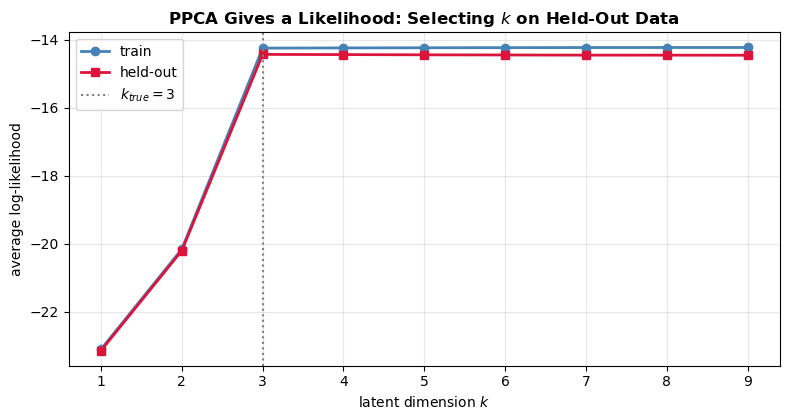

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def ppca_fit(X, k, ddof=0):
    # Closed-form PPCA MLE (Tipping & Bishop, 1999). ddof=1 mimics sklearn's 1/(N-1) covariance.
    N, D = X.shape
    mu = X.mean(axis=0)
    Xc = X - mu
    _, sing, Vt = np.linalg.svd(Xc, full_matrices=False)
    lam = np.zeros(D)
    lam[:len(sing)] = sing ** 2 / (N - ddof)
    sigma2 = lam[k:].mean() if k < D else 0.0
    Uk = Vt[:k].T
    W = Uk * np.sqrt(np.maximum(lam[:k] - sigma2, 0.0))     # R = I
    return {"mu": mu, "W": W, "sigma2": sigma2, "eigvals": lam, "Uk": Uk}

def ppca_loglik(model, X):
    # Average log-likelihood log N(x | mu, W W^T + sigma^2 I), using Woodbury / log-det lemma
    W, mu, s2 = model["W"], model["mu"], model["sigma2"]
    D, k = W.shape
    M = W.T @ W + s2 * np.eye(k)
    Xc = X - mu
    # x^T C^{-1} x = (||x||^2 - x^T W M^{-1} W^T x) / sigma^2
    XW = Xc @ W
    quad = (np.sum(Xc ** 2, axis=1) - np.sum(XW * np.linalg.solve(M, XW.T).T, axis=1)) / s2
    logdet = (D - k) * np.log(s2) + np.linalg.slogdet(M)[1]
    return np.mean(-0.5 * (D * np.log(2 * np.pi) + logdet + quad))

ppca = ppca_fit(X_syn, k=k_true)
print(f"sigma^2_ML = {ppca['sigma2']:.4f}   (true sigma^2 = {sigma2_true})")

C_ml = ppca["W"] @ ppca["W"].T + ppca["sigma2"] * np.eye(D_syn)
U_all = pca_syn["all_components"]
print("u_i^T C_ML u_i :", np.round(np.einsum("di,de,ei->i", U_all, C_ml, U_all), 4))
print("lambda_i       :", np.round(pca_syn["eigvals"], 4))

# The column space of W_ML is the principal subspace: compare projection matrices
P_W = ppca["W"] @ np.linalg.solve(ppca["W"].T @ ppca["W"], ppca["W"].T)
P_U = ppca["Uk"] @ ppca["Uk"].T
print("span(W_ML) == span(U_k):", np.allclose(P_W, P_U))
# ... and how close it is to the TRUE subspace span(W_true)
P_true = W_true @ np.linalg.solve(W_true.T @ W_true, W_true.T)
print(f"||P_ML - P_true||_F = {np.linalg.norm(P_U - P_true):.4f}")

# Any rotation R gives the same likelihood
theta = 1.1
R = np.eye(k_true); R[1:, 1:] = [[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]]
ppca_rot = dict(ppca, W=ppca["W"] @ R)
print(f"loglik(W_ML) = {ppca_loglik(ppca, X_syn):.6f}   loglik(W_ML R) = {ppca_loglik(ppca_rot, X_syn):.6f}")

# Choosing k by held-out log-likelihood (something classical PCA cannot do)
rng = np.random.default_rng(5)
X_test_syn = (rng.normal(size=(N_syn, k_true)) @ W_true.T + mu_true_syn
              + np.sqrt(sigma2_true) * rng.normal(size=(N_syn, D_syn)))
ks = range(1, D_syn)
ll_train = [ppca_loglik(ppca_fit(X_syn, k), X_syn) for k in ks]
ll_test = [ppca_loglik(ppca_fit(X_syn, k), X_test_syn) for k in ks]

fig, ax = plt.subplots(figsize=(8, 4.3))
ax.plot(list(ks), ll_train, "o-", lw=2, color="steelblue", label="train")
ax.plot(list(ks), ll_test, "s-", lw=2, color="crimson", label="held-out")
ax.axvline(k_true, color="gray", ls=":", label=fr"$k_{{true}}={k_true}$")
ax.set_xlabel("latent dimension $k$"); ax.set_ylabel("average log-likelihood")
ax.set_title("PPCA Gives a Likelihood: Selecting $k$ on Held-Out Data", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Probabilistic PCA III: The Posterior and the Limit $\sigma^2\to0$

In classical PCA the "encoding" of a point is a deterministic projection. In PPCA it is the **posterior** over the latent variable. Both $p(\mathbf z)$ and $p(\mathbf x\mid\mathbf z)$ are Gaussian and linear, so Bayes' rule for linear-Gaussian models (Bishop eq. 2.116) gives a Gaussian posterior (Bishop eq. 12.42):

$$
\boxed{\;
p(\mathbf z\mid\mathbf x)=\mathcal N\!\Big(\mathbf z\ \Big|\ M^{-1}W^\top(\mathbf x-\boldsymbol\mu),\ \ \sigma^2M^{-1}\Big),
\qquad M=W^\top W+\sigma^2I_k\;}
$$

*(Quick check by completing the square: $\ln p(\mathbf z\mid\mathbf x)=-\tfrac12\mathbf z^\top\mathbf z-\tfrac1{2\sigma^2}\lVert\mathbf x-\boldsymbol\mu-W\mathbf z\rVert^2+\text{const}$; the quadratic term in $\mathbf z$ is $-\tfrac1{2\sigma^2}\mathbf z^\top(\sigma^2I+W^\top W)\mathbf z=-\tfrac1{2\sigma^2}\mathbf z^\top M\mathbf z$, giving precision $M/\sigma^2$; the linear term $\tfrac1{\sigma^2}\mathbf z^\top W^\top(\mathbf x-\boldsymbol\mu)$ gives mean $M^{-1}W^\top(\mathbf x-\boldsymbol\mu)$.)*

- The posterior **covariance** $\sigma^2M^{-1}$ does not depend on $\mathbf x$: every point is encoded with the same uncertainty.
- The **probabilistic projection** of $\mathbf x$ back into data space is $W\,\mathbb E[\mathbf z\mid\mathbf x]+\boldsymbol\mu$.

### The limit $\sigma^2\to0$: back to PCA

As $\sigma^2\to0$: $M\to W^\top W$, the posterior covariance $\sigma^2M^{-1}\to0$ (the posterior collapses to a point), and

$$
\mathbb E[\mathbf z\mid\mathbf x]\ \longrightarrow\ (W^\top W)^{-1}W^\top(\mathbf x-\boldsymbol\mu),
\qquad
W\,\mathbb E[\mathbf z\mid\mathbf x]+\boldsymbol\mu\ \longrightarrow\ \boldsymbol\mu+\underbrace{W(W^\top W)^{-1}W^\top}_{P\text{ of Section 2}}(\mathbf x-\boldsymbol\mu),
$$

i.e. exactly the **orthogonal projection** onto the principal subspace — the coordinates $\boldsymbol\lambda=(B^\top B)^{-1}B^\top\mathbf x$ of Section 2 with $B=W$. Moreover $W_{ML}\to U_k\Lambda_k^{1/2}R$, so (with $R=I$) $\mathbb E[\mathbf z\mid\mathbf x]\to\Lambda_k^{-1/2}U_k^\top(\mathbf x-\bar{\mathbf x})$: the classical PCA scores, **whitened** to unit variance. Classical PCA is the zero-noise limit of PPCA.

**For $\sigma^2>0$** the posterior mean is *not* an orthogonal projection: $M^{-1}$ shrinks the coordinates, so $W\mathbb E[\mathbf z\mid\mathbf x]+\boldsymbol\mu$ is pulled **towards the mean** compared to the orthogonal projection (Bishop §12.2) — the prior $\mathcal N(\mathbf 0,I)$ on $\mathbf z$ acts as a regularizer, a ridge-like shrinkage. Concretely, along $\mathbf u_i$ the shrinkage factor is $(\lambda_i-\sigma^2)/\lambda_i$.

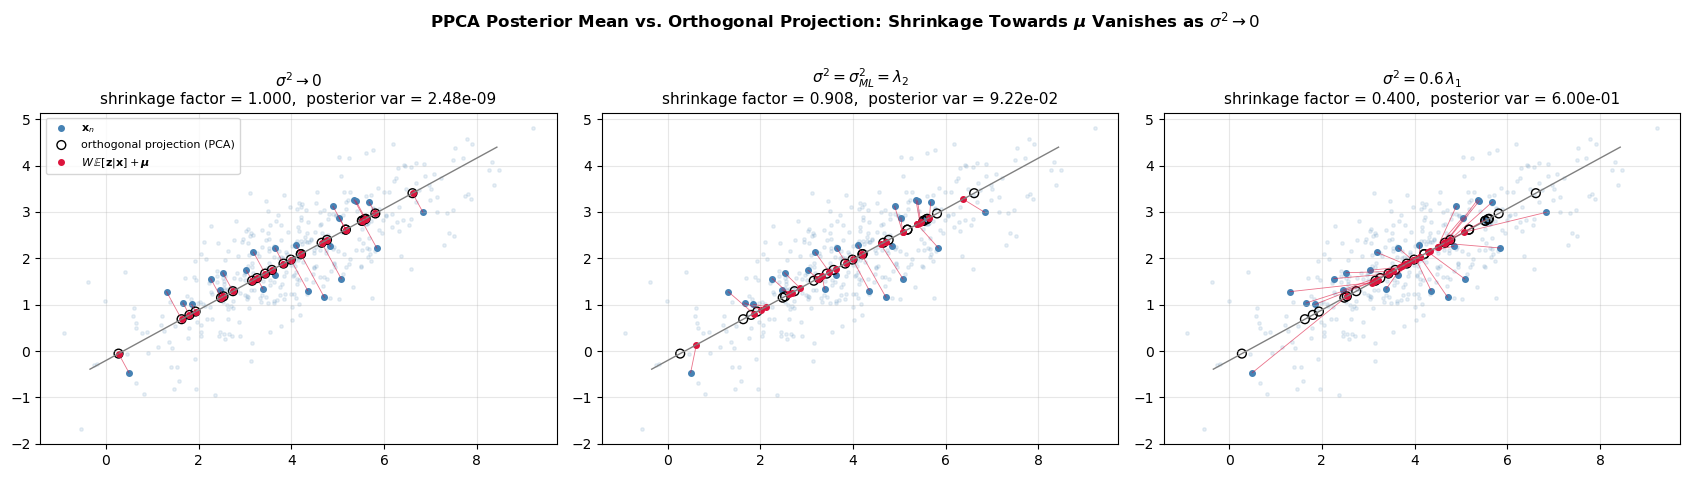

sigma^2 =  2.47e-01:  max|E[z|x] - whitened PCA scores| = 3.41e-02   max posterior var = 1.99e-02
sigma^2 =  1.00e-02:  max|E[z|x] - whitened PCA scores| = 1.37e-03   max posterior var = 8.06e-04
sigma^2 =  1.00e-04:  max|E[z|x] - whitened PCA scores| = 1.37e-05   max posterior var = 8.06e-06
sigma^2 =  1.00e-08:  max|E[z|x] - whitened PCA scores| = 1.37e-09   max posterior var = 8.06e-10


In [13]:
import numpy as np
import matplotlib.pyplot as plt

def ppca_posterior(W, mu, sigma2, X):
    k = W.shape[1]
    M = W.T @ W + sigma2 * np.eye(k)
    mean = np.linalg.solve(M, W.T @ (X - mu).T).T            # (N, k)
    cov = sigma2 * np.linalg.inv(M)                           # (k, k), same for every x
    return mean, cov

# 2D data of Section 3, k = 1. For each sigma^2 use W(sigma^2) = u_1 sqrt(lambda_1 - sigma^2).
lam_2d, U_2d = pca2["eigvals"], pca2["all_components"]
u1 = U_2d[:, [0]]
idx = np.random.default_rng(3).choice(len(X2), 25, replace=False)
x_orth = x_bar + (X2[idx] - x_bar) @ u1 @ u1.T            # classical PCA projection

sigma2_ml_2d = lam_2d[1]                                    # (D - k) = 1 discarded eigenvalue
settings = [(1e-8, r"$\sigma^2\to0$"),
            (sigma2_ml_2d, r"$\sigma^2=\sigma^2_{ML}=\lambda_2$"),
            (0.6 * lam_2d[0], r"$\sigma^2=0.6\,\lambda_1$")]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, (s2, title) in zip(axes, settings):
    W_s = u1 * np.sqrt(lam_2d[0] - s2)
    Ez, Cz = ppca_posterior(W_s, x_bar, s2, X2[idx])
    x_prob = Ez @ W_s.T + x_bar
    ax.scatter(X2[:, 0], X2[:, 1], s=6, alpha=0.12, color="steelblue")
    line = x_bar + np.outer(np.linspace(-5, 5, 2), u1[:, 0])
    ax.plot(line[:, 0], line[:, 1], color="gray", lw=1)
    ax.scatter(X2[idx, 0], X2[idx, 1], s=16, color="steelblue", label=r"$\mathbf{x}_n$")
    ax.scatter(x_orth[:, 0], x_orth[:, 1], s=40, facecolor="none", edgecolor="black", label="orthogonal projection (PCA)")
    ax.scatter(x_prob[:, 0], x_prob[:, 1], s=16, color="crimson", label=r"$W\,\mathbb{E}[\mathbf{z}|\mathbf{x}]+\boldsymbol{\mu}$")
    for a, p in zip(X2[idx], x_prob):
        ax.plot([a[0], p[0]], [a[1], p[1]], color="crimson", lw=0.6, alpha=0.6)
    shrink = (lam_2d[0] - s2) / lam_2d[0]
    ax.set_title(f"{title}\nshrinkage factor = {shrink:.3f},  posterior var = {Cz[0, 0]:.2e}", fontsize=11)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="upper left")
plt.suptitle(r"PPCA Posterior Mean vs. Orthogonal Projection: Shrinkage Towards $\boldsymbol{\mu}$ Vanishes as $\sigma^2\to0$",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Numerical check of the limit on the 10-D synthetic data
Lk = pca_syn["eigvals"][:k_true]
Uk_syn = pca_syn["all_components"][:, :k_true]
for s2 in [ppca["sigma2"], 1e-2, 1e-4, 1e-8]:
    W_s = Uk_syn * np.sqrt(Lk - s2)
    Ez, Cz = ppca_posterior(W_s, X_syn.mean(axis=0), s2, X_syn)
    z_whitened_pca = pca_transform(pca_syn, X_syn)[:, :k_true] / np.sqrt(Lk)
    print(f"sigma^2 = {s2:9.2e}:  max|E[z|x] - whitened PCA scores| = {np.abs(Ez - z_whitened_pca).max():.2e}"
          f"   max posterior var = {np.diag(Cz).max():.2e}")

---
## 13. Comparison with `sklearn.decomposition.PCA`

`sklearn.decomposition.PCA` centers the data and computes an SVD (Section 8); with the default `svd_solver="auto"` it may use a randomized solver for large inputs. Correspondences with our notation:

| sklearn attribute / method | Our notation | Note |
|---|---|---|
| `mean_` | $\bar{\mathbf x}$ | |
| `components_` | $U_k^\top$ (rows!) | defined up to sign |
| `explained_variance_` | $\lambda_i\cdot\frac{N}{N-1}$ | sklearn uses the unbiased $1/(N-1)$ |
| `explained_variance_ratio_` | $\lambda_i/\sum_j\lambda_j$ | the factor cancels |
| `singular_values_` | $\sigma_i$ of $X_c$ | |
| `noise_variance_` | $\sigma^2_{ML}\cdot\frac{N}{N-1}$ | the PPCA noise estimate (Tipping & Bishop) |
| `transform(X)` | $X_cU_k$ | `whiten=True` divides by $\sqrt{\lambda_i}$ |
| `inverse_transform(Z)` | $ZU_k^\top+\mathbf 1\bar{\mathbf x}^\top$ | |
| `get_covariance()` | $C=WW^\top+\sigma^2I$ | PPCA covariance |
| `score(X)` | average PPCA log-likelihood | |

Note that sklearn's `score` is the **PPCA** log-likelihood of Section 11 — even the "classical" PCA estimator is backed by the probabilistic model.

In [14]:
import numpy as np
from sklearn.decomposition import PCA

k = 10
pca_sk = PCA(n_components=k).fit(X_dig)
ours = pca_fit_svd(X_dig, k=D_dig)
N = X_dig.shape[0]
corr = N / (N - 1)

# components: equal up to sign
sign_agree = np.abs(np.sum(pca_sk.components_ * ours["components"][:, :k].T, axis=1))
print("mean_ matches                    :", np.allclose(pca_sk.mean_, ours["mean"]))
print("|<components_, U_k>| (all = 1)   :", np.allclose(sign_agree, 1.0))
print("explained_variance_ = lambda*N/(N-1):", np.allclose(pca_sk.explained_variance_, ours["eigvals"][:k] * corr))
print("explained_variance_ratio_ matches:", np.allclose(pca_sk.explained_variance_ratio_, ours["eigvals"][:k] / ours["eigvals"].sum()))
print("singular_values_ matches         :", np.allclose(pca_sk.singular_values_, ours["singular_values"][:k]))

# transform / inverse_transform, after aligning signs
signs = np.sign(np.sum(pca_sk.components_ * ours["components"][:, :k].T, axis=1))
Uk_aligned = ours["components"][:, :k] * signs
Z_ours = (X_dig - ours["mean"]) @ Uk_aligned
print("transform matches                :", np.allclose(pca_sk.transform(X_dig), Z_ours))
print("inverse_transform matches        :", np.allclose(pca_sk.inverse_transform(Z_ours), Z_ours @ Uk_aligned.T + ours["mean"]))

# PPCA quantities: noise_variance_, get_covariance(), score() -- compare with ddof=1 to match sklearn
ppca_dig = ppca_fit(X_dig, k, ddof=1)
C_ours = ppca_dig["W"] @ ppca_dig["W"].T + ppca_dig["sigma2"] * np.eye(D_dig)
print(f"\nnoise_variance_ (sklearn) = {pca_sk.noise_variance_:.6f}   sigma^2_ML (ours, ddof=1) = {ppca_dig['sigma2']:.6f}")
print("get_covariance() == W W^T + sigma^2 I :", np.allclose(pca_sk.get_covariance(), C_ours))
print(f"score (sklearn) = {pca_sk.score(X_dig):.6f}   ppca_loglik (ours) = {ppca_loglik(ppca_dig, X_dig):.6f}")

# whiten=True gives unit-variance scores = sigma^2 -> 0 limit of the PPCA posterior mean
pca_w = PCA(n_components=k, whiten=True).fit(X_dig)
print("\nwhitened scores have unit variance:", np.allclose(pca_w.transform(X_dig).var(axis=0, ddof=1), 1.0))

ImportError: DLL load failed while importing _loss: Un criterio di controllo dell'applicazione ha bloccato il file.

---
## 14. Summary

| Concept | Key Formula | Core Insight |
|---------|-------------|---------------|
| Orthogonal projection | $P=B(B^\top B)^{-1}B^\top$, $\;P=BB^\top$ if orthonormal | $P^2=P=P^\top$; residual $\perp$ subspace; closest point in $U$ |
| Sample covariance | $S=\frac1N X_c^\top X_c$ | Symmetric PSD; $\operatorname{Var}(\mathbf u^\top\mathbf x)=\mathbf u^\top S\mathbf u$ |
| Max variance | $\max_{\lVert\mathbf u\rVert=1}\mathbf u^\top S\mathbf u\Rightarrow S\mathbf u=\lambda\mathbf u$ | Lagrange multiplier = eigenvalue = variance along $\mathbf u$ |
| Min reconstruction error | $J_{\min}=\sum_{i>k}\lambda_i$ | $\operatorname{tr}S=$ retained $+$ error: the two views coincide |
| Encode / decode | $\mathbf z=U_k^\top(\mathbf x-\bar{\mathbf x})$, $\;\tilde{\mathbf x}=\bar{\mathbf x}+U_k\mathbf z$ | Optimal linear autoencoder |
| Choosing $k$ | $\sum_{i\le k}\lambda_i/\sum_i\lambda_i$, scree plot | Elbow / variance threshold / held-out PPCA likelihood |
| SVD | $X_c=U\Sigma V^\top$, $\;\lambda_i=\sigma_i^2/N$, PCs $=$ columns of $V$ | Stable (no $X^\top X$); Eckart–Young: best rank-$k$ approximation |
| PPCA model | $\mathbf z\sim\mathcal N(\mathbf 0,I)$, $\mathbf x=W\mathbf z+\boldsymbol\mu+\boldsymbol\varepsilon$ | Continuous latent variable; marginal $\mathcal N(\boldsymbol\mu,WW^\top+\sigma^2I)$ |
| PPCA MLE | $\sigma^2_{ML}=\frac{1}{D-k}\sum_{i>k}\lambda_i$, $\;W_{ML}=U_k(\Lambda_k-\sigma^2I)^{1/2}R$ | Closed form; spans the principal subspace; $R$ unidentifiable |
| PPCA posterior | $p(\mathbf z\mid\mathbf x)=\mathcal N(M^{-1}W^\top(\mathbf x-\boldsymbol\mu),\sigma^2M^{-1})$ | Shrinks towards $\boldsymbol\mu$; $\sigma^2\to0$ recovers orthogonal projection (PCA) |
| sklearn | `PCA` = SVD + PPCA (`noise_variance_`, `score`) | Uses $1/(N-1)$: eigenvalues differ by $N/(N-1)$ |

---

**Next →** `05_gaussian_mixture_models.ipynb`: from a continuous latent variable to a **discrete** one — mixtures of Gaussians and the Expectation-Maximization algorithm (which also fits PPCA, Bishop §12.2.2).